# Deep Learning PR1 — Breast Cancer Wisconsin (Diagnostic)

**Topics:** SLP, MLP, Data Scaling, Activation Functions, Early Stopping, Dropout, L1/L2/L1-L2 Regularization  
**Framework:** TensorFlow/Keras   
**Dataset:** Breast Cancer Wisconsin (Diagnostic), loaded from `sklearn.datasets.load_breast_cancer()`

This notebook follows the same project concept and task order. The implementation and experiments are preserved; the presentation and visualization styling have been refreshed for a different look.


## Submission checklist covered

1. Dataset loading, EDA, class distribution, correlation heatmap, train/test split and StandardScaler.
2. Single-Layer Perceptron (SLP) baseline.
3. Multi-Layer Perceptron (MLP) with ReLU, Tanh and Sigmoid comparisons.
4. Early Stopping experiment and comparison with a model without Early Stopping.
5. Dropout experiment with rates 0.1, 0.3 and 0.5.
6. L2, L1 and L1-L2 regularization comparison.
7. Final comparison table, business/clinical insight discussion and best-model selection.

The notebook also includes explanations of the requested concepts in Markdown cells.

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization style (presentation only; model/data logic is unchanged)
sns.set_theme(style="whitegrid", context="notebook")
PLOT_COLORS = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Task 1 — Dataset Loading, EDA & Preprocessing

The supplied brief specifies the Breast Cancer Wisconsin (Diagnostic) dataset, with 569 samples, 30 numeric features and a binary target. The target is encoded as **0 = malignant** and **1 = benign**.

For neural networks, feature scaling is important because the input features have very different numeric ranges. StandardScaler transforms each feature approximately to mean 0 and standard deviation 1.

In [ ]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

df = df.rename(columns={"target": "target"})

print("Shape:", df.shape)
display(df.head())
display(df.describe().T.head(10))

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744



Missing values: 0
Duplicate rows: 0


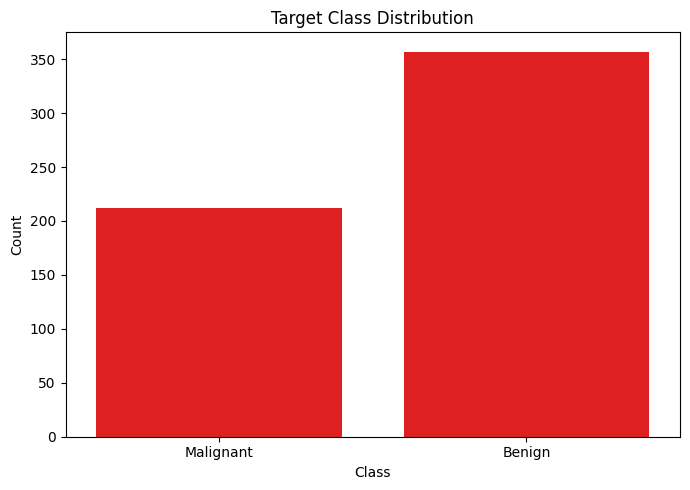

target
Malignant    212
Benign       357
Name: count, dtype: int64


In [ ]:
class_counts = df["target"].value_counts().sort_index()

class_labels = {
    0: "Malignant",
    1: "Benign"
}

plt.figure(figsize=(8, 5))
bars = sns.barplot(
    x=[class_labels[i] for i in class_counts.index],
    y=class_counts.values,
    palette=[PLOT_COLORS[0], PLOT_COLORS[2]],
    edgecolor="black",
    linewidth=0.8
)

plt.title("Target Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.ylim(0, max(class_counts.values) * 1.15)

for bar, value in zip(bars.patches, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        str(value),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print(class_counts.rename(index=class_labels))


### EDA interpretation

The class distribution should be checked before model training because accuracy alone can be misleading when one class is more common. The dataset is not perfectly balanced, so precision, recall and F1-score are also reported.

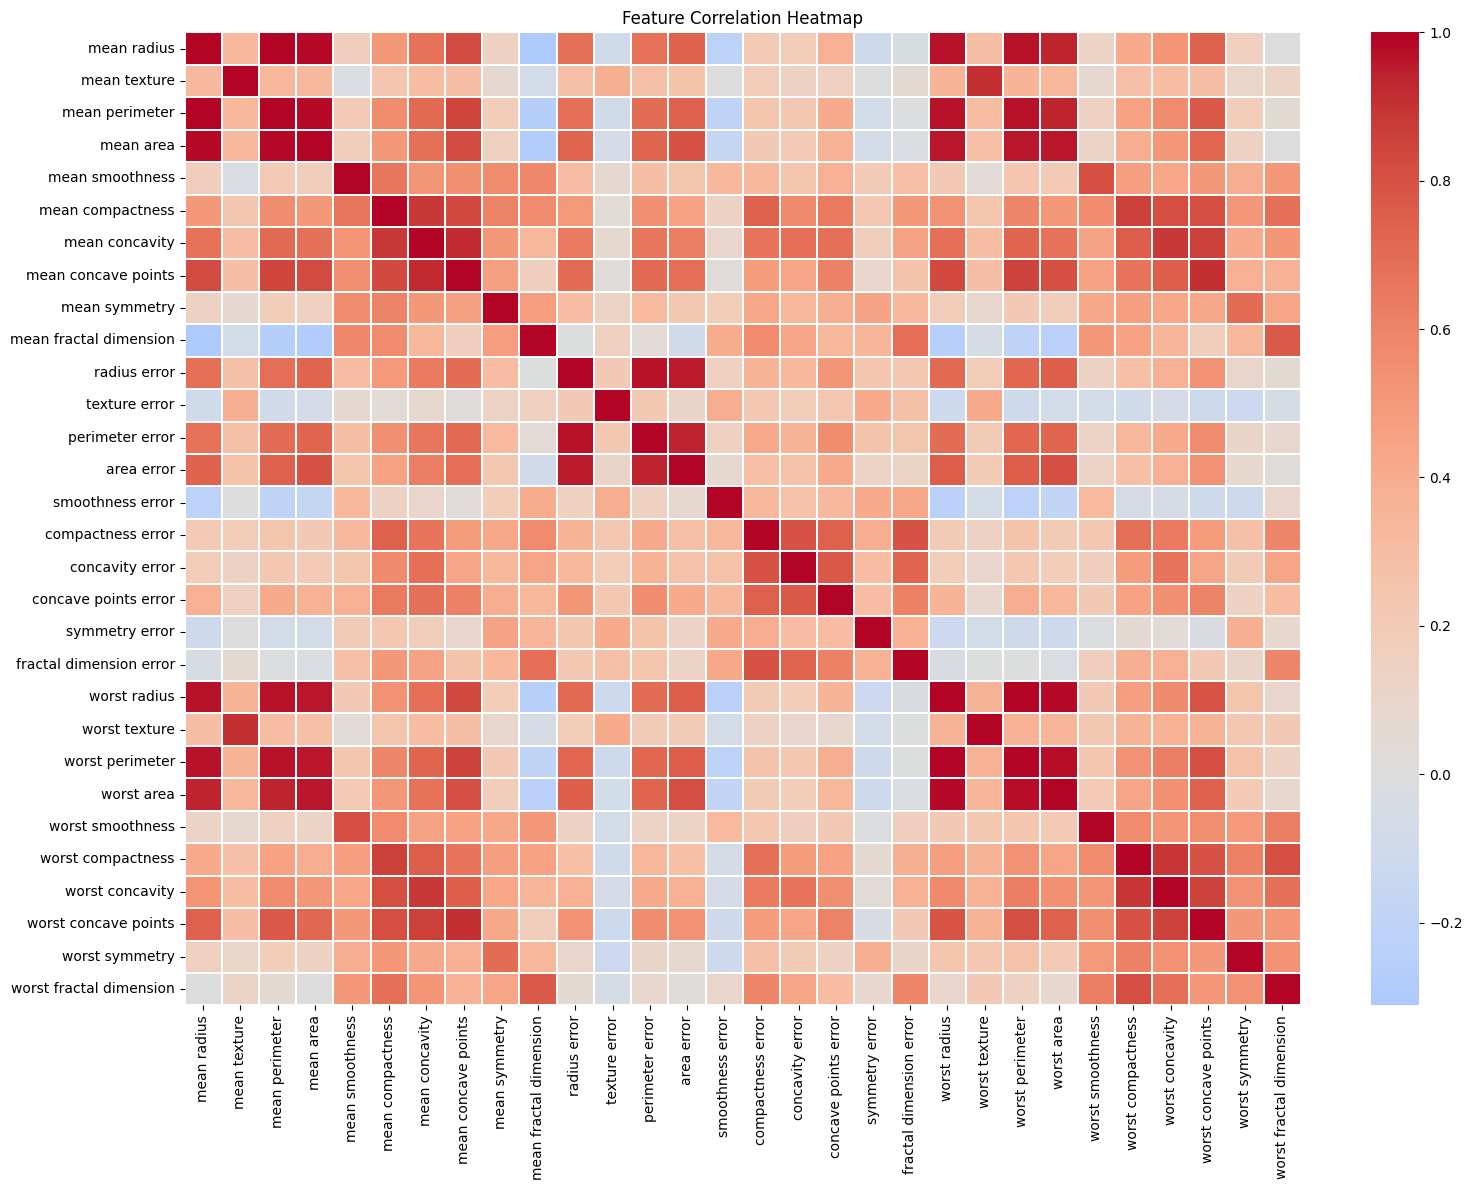

In [ ]:
corr = df.drop(columns="target").corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    linewidths=0.35,
    linecolor="white",
    cbar_kws={"shrink": 0.85, "label": "Correlation"}
)
plt.title("Feature Correlation Map", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Correlation interpretation

Highly correlated features indicate redundancy among measurements. For neural networks, StandardScaler is still required because correlation and scale are different issues: correlation describes relationships between features, while scaling controls their numeric ranges.

In [ ]:
X = df.drop(columns="target").astype("float32")
y = df["target"].astype("int32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts :", np.bincount(y_test))
print("Scaled train mean (first 5):", np.round(X_train_scaled.mean(axis=0)[:5], 4))
print("Scaled train std  (first 5):", np.round(X_train_scaled.std(axis=0)[:5], 4))

X_train: (455, 30)
X_test : (114, 30)
Train class counts: [170 285]
Test class counts : [42 72]
Scaled train mean (first 5): [ 0.  0. -0.  0.  0.]
Scaled train std  (first 5): [1. 1. 1. 1. 1.]


### Why scaling is important for neural networks

Gradient-based optimizers update weights using the loss gradient. If one feature ranges from 0–1 while another ranges into the thousands, the larger-scale feature can dominate the optimization dynamics. Standardization puts features on a comparable scale, usually making optimization more stable and efficient.

# Task 2 — Single-Layer Perceptron (SLP) Baseline

The SLP is the baseline neural model. It has one sigmoid output neuron and no hidden layer. The sigmoid output represents the estimated probability of the positive class.

**Loss:** binary cross-entropy  
**Optimizer:** Adam  
**Metric:** accuracy

In [ ]:
def build_slp():
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(1, activation="sigmoid")
    ], name="SLP")
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

slp = build_slp()
slp.summary()

Model: "SLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
slp_history = slp.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    verbose=0
)

slp_test_loss, slp_test_acc = slp.evaluate(X_test_scaled, y_test, verbose=0)
slp_prob = slp.predict(X_test_scaled, verbose=0).ravel()
slp_pred = (slp_prob >= 0.5).astype(int)

print(f"SLP Test Loss: {slp_test_loss:.4f}")
print(f"SLP Test Accuracy: {slp_test_acc:.4f}")
print(classification_report(y_test, slp_pred, target_names=["Malignant", "Benign"]))

SLP Test Loss: 0.1855
SLP Test Accuracy: 0.9386
              precision    recall  f1-score   support

   Malignant       0.95      0.88      0.91        42
      Benign       0.93      0.97      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



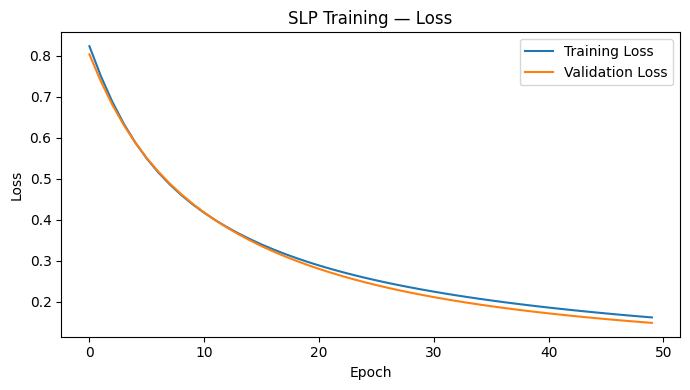

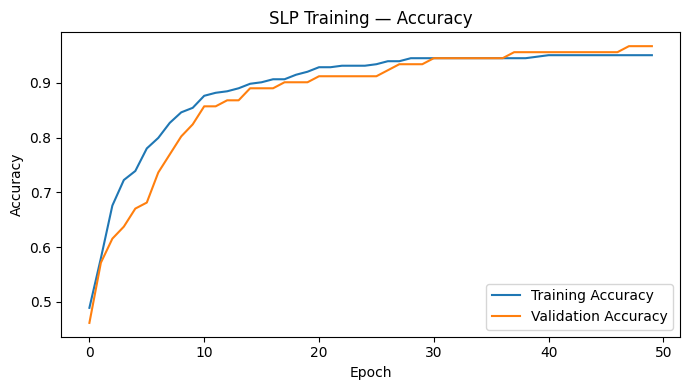

In [ ]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 4.5))
    plt.plot(
        hist["loss"],
        label="Training Loss",
        color=PLOT_COLORS[0],
        linewidth=2.2
    )
    plt.plot(
        hist["val_loss"],
        label="Validation Loss",
        color=PLOT_COLORS[1],
        linewidth=2.2,
        linestyle="--"
    )
    plt.title(title + " | Loss", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(frameon=True)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.plot(
        hist["accuracy"],
        label="Training Accuracy",
        color=PLOT_COLORS[2],
        linewidth=2.2
    )
    plt.plot(
        hist["val_accuracy"],
        label="Validation Accuracy",
        color=PLOT_COLORS[3],
        linewidth=2.2,
        linestyle="--"
    )
    plt.title(title + " | Accuracy", fontsize=14, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(frameon=True)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_history(slp_history, "SLP Training")


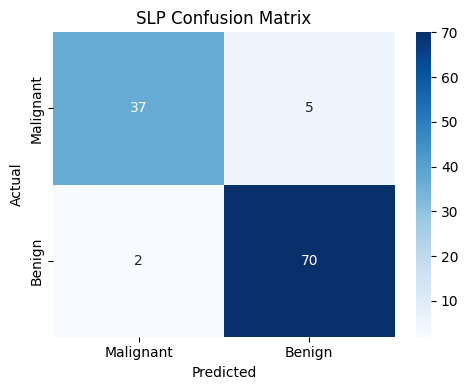

In [ ]:
cm = confusion_matrix(y_test, slp_pred)

plt.figure(figsize=(6, 4.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="crest",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar=False,
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"],
    annot_kws={"fontsize": 13, "fontweight": "bold"}
)
plt.title("SLP Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()


### SLP limitations — Markdown answer

An SLP is a linear decision model. With 30 input features, it learns a weighted sum followed by a sigmoid function. It cannot learn complex hierarchical feature interactions in the same way as a network with hidden layers and nonlinear activations. This motivates the MLP in Task 3.

# Task 3 — Multi-Layer Perceptron (MLP) and Activation Functions

A hidden layer with a nonlinear activation allows the network to learn nonlinear decision boundaries. We compare **ReLU, Tanh and Sigmoid** while keeping the architecture and training settings consistent.

In [ ]:
def build_activation_mlp(activation):
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation=activation),
        layers.Dense(32, activation=activation),
        layers.Dense(1, activation="sigmoid")
    ], name=f"MLP_{activation}")
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

activation_results = {}
activation_histories = {}

for activation in ["relu", "tanh", "sigmoid"]:
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_activation_mlp(activation)
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.20,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    prob = model.predict(X_test_scaled, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    activation_results[activation] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }
    activation_histories[activation] = history

activation_table = pd.DataFrame(activation_results).T.sort_values("F1", ascending=False)
display(activation_table.round(4))

,Accuracy,Precision,Recall,F1
tanh,0.9649,0.9722,0.9722,0.9722
relu,0.9649,0.9857,0.9583,0.9718
sigmoid,0.9474,0.9853,0.9306,0.9571


### Why hidden layers — Markdown answer

Each hidden layer applies a learned affine transformation followed by a nonlinear activation. Stacking layers lets the network transform the original measurements into increasingly useful representations. Without nonlinear activations, multiple dense layers collapse into an overall linear transformation, so depth would not provide the intended nonlinear modeling power.

### Activation functions — Markdown answer

- **ReLU:** `max(0, x)`. It is simple and usually trains efficiently because positive inputs have a constant gradient.
- **Tanh:** maps values to approximately `[-1, 1]`. It is centered around zero but can saturate at large positive/negative values.
- **Sigmoid:** maps values to `(0, 1)`. It is useful for the final binary output but can suffer from very small gradients in saturated regions when used throughout deep hidden layers.

The experiment above records test metrics for all three and identifies the best-performing activation on this split.

In [ ]:
best_activation = activation_table.index[0]
best_activation_metrics = activation_table.loc[best_activation].to_dict()
print("Best activation by test F1:", best_activation)
print({k: round(v, 4) for k, v in best_activation_metrics.items()})

Best activation by test F1: tanh
{'Accuracy': 0.9649, 'Precision': 0.9722, 'Recall': 0.9722, 'F1': 0.9722}


# Task 4 — Early Stopping

Early Stopping monitors validation loss and stops training when the validation metric stops improving. Restoring the best weights helps prevent the final model from being worse than the best validation point.

We compare an EarlyStopping model with a same-architecture model trained for the full epoch budget.

In [ ]:
def build_earlystop_mlp():
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

tf.keras.backend.clear_session()
early_model = build_earlystop_mlp()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

early_history = early_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print("Epochs actually trained:", len(early_history.history["loss"]))
print("Best validation loss:", min(early_history.history["val_loss"]))

Epoch 58: early stopping
Restoring model weights from the end of the best epoch: 43.
Epochs actually trained: 58
Best validation loss: 0.017959922552108765


In [ ]:
tf.keras.backend.clear_session()
full_model = build_earlystop_mlp()

full_history = full_model.fit(
    X_train_scaled, y_train,
    validation_split=0.20,
    epochs=300,
    batch_size=32,
    verbose=0
)

def evaluate_binary_model(model):
    prob = model.predict(X_test_scaled, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    }, pred

early_metrics, early_pred = evaluate_binary_model(early_model)
full_metrics, full_pred = evaluate_binary_model(full_model)

print("Early Stopping:", {k: round(v, 4) for k, v in early_metrics.items()})
print("Without Early Stopping:", {k: round(v, 4) for k, v in full_metrics.items()})

Early Stopping: {'Accuracy': 0.9474, 'Precision': 0.9853, 'Recall': 0.9306, 'F1': 0.9571}
Without Early Stopping: {'Accuracy': 0.9561, 'Precision': 0.9855, 'Recall': 0.9444, 'F1': 0.9645}


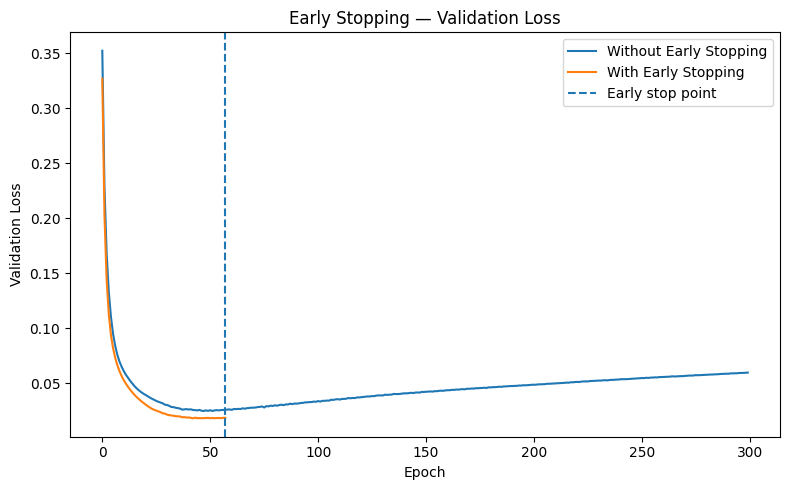

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    full_history.history["val_loss"],
    label="Without Early Stopping",
    color=PLOT_COLORS[1],
    linewidth=2.2
)
plt.plot(
    early_history.history["val_loss"],
    label="With Early Stopping",
    color=PLOT_COLORS[0],
    linewidth=2.2
)

stop_epoch = len(early_history.history["loss"]) - 1
plt.axvline(
    stop_epoch,
    color=PLOT_COLORS[3],
    linestyle=":",
    linewidth=2,
    label="Early stop point"
)
plt.scatter(
    [stop_epoch],
    [early_history.history["val_loss"][-1]],
    color=PLOT_COLORS[3],
    s=55,
    zorder=5
)

plt.title("Early Stopping | Validation Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
def build_dropout_mlp(rate):
    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(rate),
        layers.Dense(32, activation="relu"),
        layers.Dropout(rate),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

dropout_results = {}
dropout_histories = {}

for rate in [0.1, 0.3, 0.5]:
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_dropout_mlp(rate)
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.20,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    metrics, pred = evaluate_binary_model(model)
    dropout_results[rate] = metrics
    dropout_histories[rate] = history

dropout_table = pd.DataFrame(dropout_results).T
dropout_table.index.name = "Dropout Rate"
display(dropout_table.round(4))

,Accuracy,Precision,Recall,F1
Dropout Rate,,,,
0.1,0.9561,0.9855,0.9444,0.9645
0.3,0.9474,0.9853,0.9306,0.9571
0.5,0.9474,0.9853,0.9306,0.9571


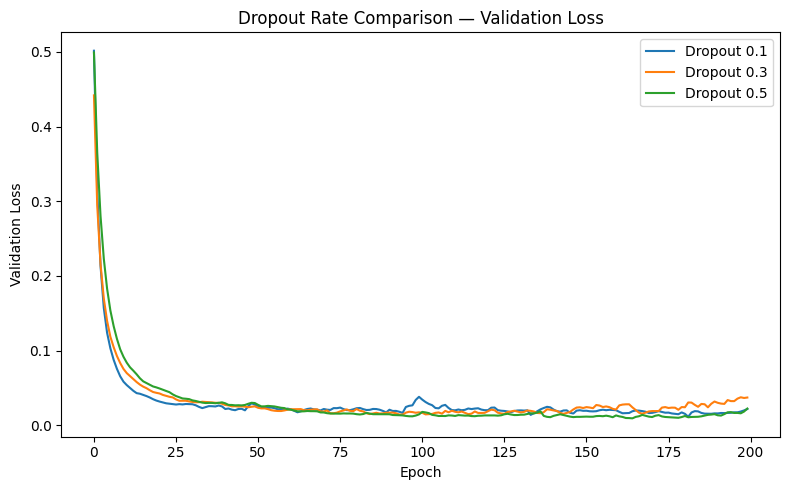

In [ ]:
plt.figure(figsize=(9, 5))
dropout_colors = [PLOT_COLORS[0], PLOT_COLORS[1], PLOT_COLORS[2]]

for (rate, history), color in zip(dropout_histories.items(), dropout_colors):
    plt.plot(
        history.history["val_loss"],
        label=f"Dropout {rate}",
        color=color,
        linewidth=2.2
    )

plt.title("Dropout Rate Comparison | Validation Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(title="Dropout Rate", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Why Dropout — Markdown answer

Dropout randomly removes activations during training, forcing the network to avoid depending too strongly on a small set of neurons. This can improve generalization and reduce overfitting. Too much dropout can also make learning harder, so the rates 0.1, 0.3 and 0.5 are compared rather than assuming the largest rate is best.

# Task 6 — Regularization: L2, L1 and L1-L2

Regularization adds a penalty to the loss function.

- **L2:** penalizes squared weights and generally encourages smaller, smoother weights.
- **L1:** penalizes absolute weights and can push some weights toward exactly zero, creating sparsity.
- **L1-L2 / ElasticNet-style:** combines both penalties.

We compare validation loss and test metrics.

In [ ]:
def build_regularized_mlp(reg_type):
    if reg_type == "L2":
        reg = regularizers.l2(0.001)
    elif reg_type == "L1":
        reg = regularizers.l1(0.001)
    elif reg_type == "L1-L2":
        reg = regularizers.l1_l2(l1=0.0005, l2=0.001)
    else:
        reg = None

    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.Dense(32, activation="relu", kernel_regularizer=reg),
        layers.Dense(1, activation="sigmoid", kernel_regularizer=reg)
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

regularization_results = {}
regularization_histories = {}

for reg_type in ["L2", "L1", "L1-L2"]:
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_regularized_mlp(reg_type)
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.20,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    metrics, pred = evaluate_binary_model(model)
    regularization_results[reg_type] = metrics
    regularization_histories[reg_type] = history

reg_table = pd.DataFrame(regularization_results).T
display(reg_table.round(4))

,Accuracy,Precision,Recall,F1
L2,0.9649,0.9857,0.9583,0.9718
L1,0.9649,0.9857,0.9583,0.9718
L1-L2,0.9561,0.9855,0.9444,0.9645


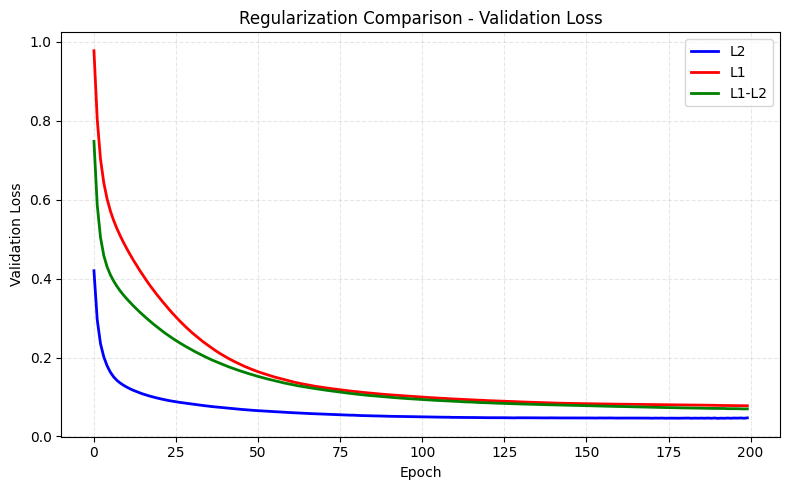

In [ ]:
plt.figure(figsize=(9, 5))

reg_colors = {
    "L2": PLOT_COLORS[0],
    "L1": PLOT_COLORS[1],
    "L1-L2": PLOT_COLORS[2]
}

for reg_type, history in regularization_histories.items():
    plt.plot(
        history.history["val_loss"],
        label=reg_type,
        color=reg_colors.get(reg_type, PLOT_COLORS[3]),
        linewidth=2.2
    )

plt.title("Regularization Comparison | Validation Loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(title="Method", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
